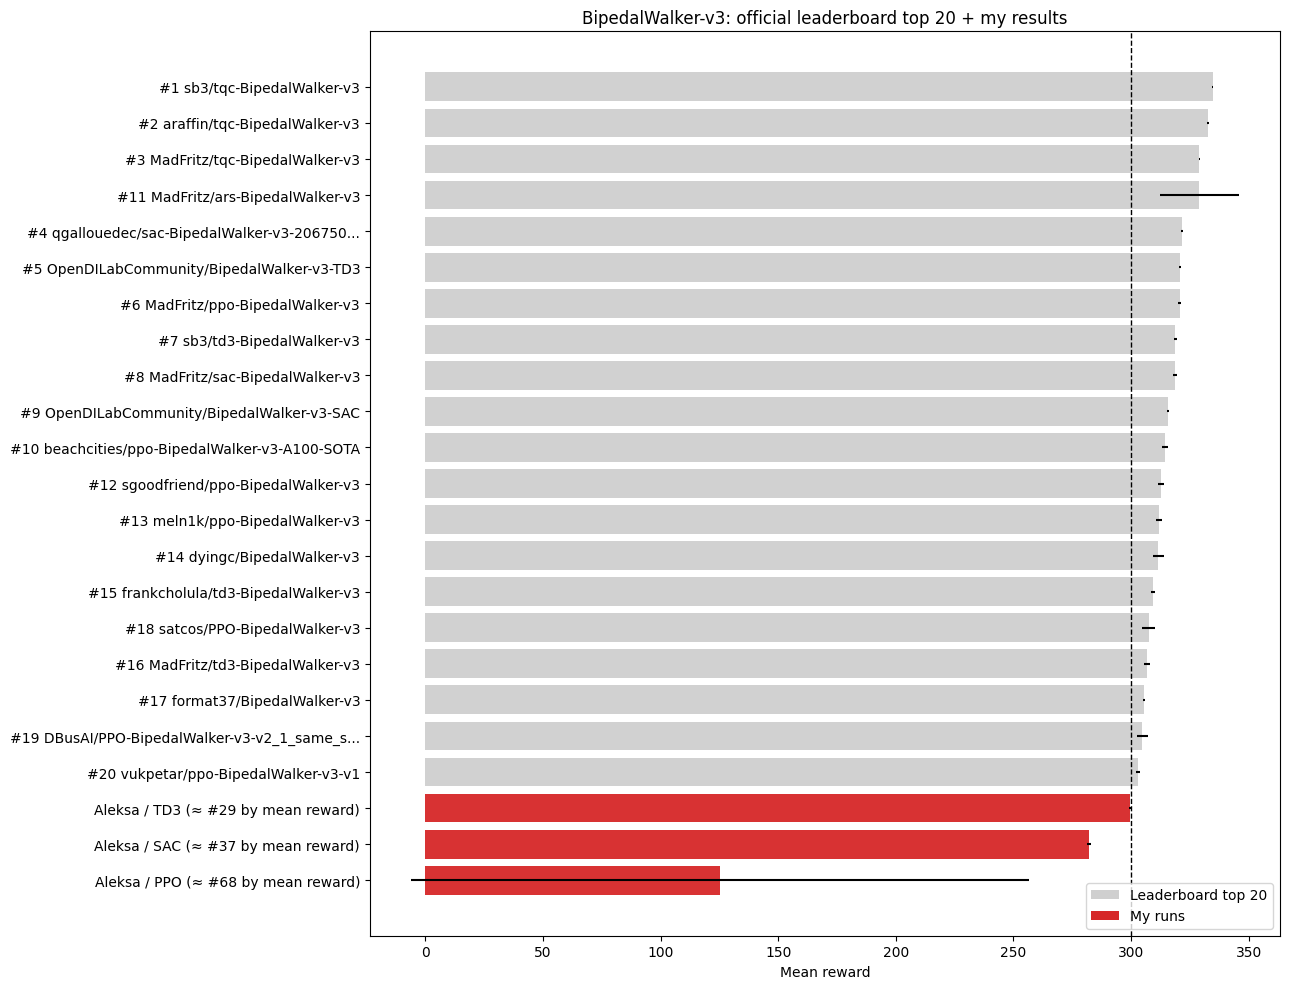

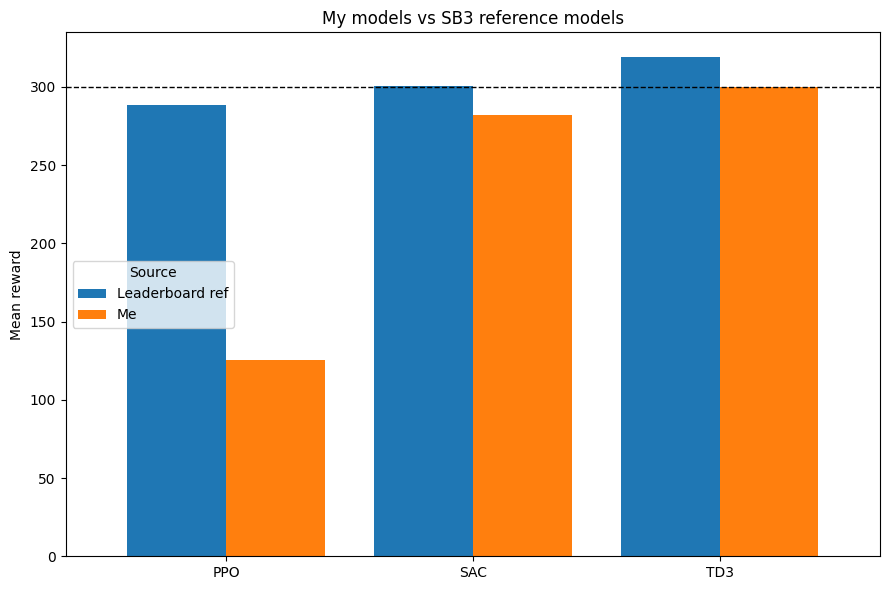


=== My approximate positions by mean reward ===
Aleksa / TD3: mean=299.54, std=0.46, approx_rank_by_mean=29
Aleksa / SAC: mean=282.08, std=0.91, approx_rank_by_mean=37
Aleksa / PPO: mean=125.28, std=131.29, approx_rank_by_mean=68


In [1]:
# pip install pandas matplotlib

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

LEADERBOARD_URL = (
    "https://huggingface.co/datasets/"
    "huggingface-projects/drlc-leaderboard-data/"
    "resolve/main/BipedalWalker-v3.csv?download=true"
)

MY_RESULTS = {
    "Aleksa / TD3": {"algo": "TD3", "mean": 299.54, "std": 0.46},
    "Aleksa / SAC": {"algo": "SAC", "mean": 282.08, "std": 0.91},
    "Aleksa / PPO": {"algo": "PPO", "mean": 125.28, "std": 131.29},
}

HF_REF_MODELS = {
    "TD3": "sb3/td3-BipedalWalker-v3",
    "SAC": "sb3/sac-BipedalWalker-v3",
    "PPO": "sb3/ppo-BipedalWalker-v3",
}


def short_label(text: str, max_len: int = 42) -> str:
    return text if len(text) <= max_len else text[: max_len - 3] + "..."


# ucitati leaderboard
df = pd.read_csv(LEADERBOARD_URL)
df.columns = [c.strip() for c in df.columns]

for col in ["Ranking", "Mean Reward", "Std Reward", "Results"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# =========
# chart 1: official leaderboard top 20 + tvoji rezultati
# =========
top20 = (
    df.sort_values("Ranking")
      .head(20)[["Ranking", "Model", "Mean Reward", "Std Reward"]]
      .copy()
)

top20["Label"] = top20.apply(
    lambda r: f'#{int(r["Ranking"])} {short_label(r["Model"])}', axis=1
)
top20["Source"] = "Leaderboard"

my_rows = []
for name, vals in MY_RESULTS.items():
    rank_by_mean = int((df["Mean Reward"] > vals["mean"]).sum() + 1)
    my_rows.append(
        {
            "Ranking": None,
            "Model": name,
            "Mean Reward": vals["mean"],
            "Std Reward": vals["std"],
            "Label": f"{name} (≈ #{rank_by_mean} by mean reward)",
            "Source": "Me",
        }
    )

my_df = pd.DataFrame(my_rows)

plot_df = pd.concat([top20, my_df], ignore_index=True)
plot_df = plot_df.sort_values("Mean Reward", ascending=True)

colors = ["#cfcfcf" if s == "Leaderboard" else "#d62728" for s in plot_df["Source"]]

plt.figure(figsize=(13, 10))
plt.barh(
    plot_df["Label"],
    plot_df["Mean Reward"],
    xerr=plot_df["Std Reward"],
    color=colors,
    alpha=0.95,
)
plt.axvline(300, linestyle="--", linewidth=1, color="black", label="Solved ≈ 300")
plt.xlabel("Mean reward")
plt.ylabel("")
plt.title("BipedalWalker-v3: official leaderboard top 20 + my results")
plt.legend(
    handles=[
        Patch(facecolor="#cfcfcf", label="Leaderboard top 20"),
        Patch(facecolor="#d62728", label="My runs"),
    ],
    loc="lower right",
)
plt.tight_layout()
plt.savefig("bipedalwalker_top20_vs_me.png", dpi=200, bbox_inches="tight")
plt.show()

# =========
# chart 2: moj PPO/SAC/TD3 vs SB3 reference PPO/SAC/TD3
# =========
compare_rows = []

for algo, model_name in HF_REF_MODELS.items():
    hf_row = df[df["Model"].str.lower() == model_name.lower()]
    if hf_row.empty:
        continue

    hf_row = hf_row.iloc[0]

    my_name = f"Aleksa / {algo}"
    my_vals = MY_RESULTS[my_name]

    compare_rows.append(
        {
            "Algorithm": algo,
            "Source": "Leaderboard ref",
            "Mean Reward": float(hf_row["Mean Reward"]),
        }
    )
    compare_rows.append(
        {
            "Algorithm": algo,
            "Source": "Me",
            "Mean Reward": my_vals["mean"],
        }
    )

cmp_df = pd.DataFrame(compare_rows)
pivot = cmp_df.pivot(index="Algorithm", columns="Source", values="Mean Reward")
pivot = pivot.reindex(["PPO", "SAC", "TD3"])

ax = pivot.plot(kind="bar", figsize=(9, 6), width=0.8)
ax.axhline(300, linestyle="--", linewidth=1, color="black")
ax.set_title("My models vs SB3 reference models")
ax.set_ylabel("Mean reward")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("bipedalwalker_me_vs_sb3_refs.png", dpi=200, bbox_inches="tight")
plt.show()

# =========
# mali pregled u terminalu
# =========
print("\n=== My approximate positions by mean reward ===")
for name, vals in MY_RESULTS.items():
    rank_by_mean = int((df["Mean Reward"] > vals["mean"]).sum() + 1)
    print(f"{name}: mean={vals['mean']:.2f}, std={vals['std']:.2f}, approx_rank_by_mean={rank_by_mean}")

Loaded policy from: artifacts\runs\standard\ppo_bipedalwalker_seed42\policy.zip
Observation dim: 24 | Action dim: 4
log_std raw shape: (256, 4)

=== Top observation indices by influence ===
 1. obs_00 -> influence=5151.8208
 2. obs_13 -> influence=4440.4448
 3. obs_02 -> influence=4371.7397
 4. obs_09 -> influence=4299.0078
 5. obs_11 -> influence=4243.6646
 6. obs_04 -> influence=4222.4805
 7. obs_03 -> influence=4129.1909
 8. obs_12 -> influence=3965.8916
 9. obs_10 -> influence=3964.9160
10. obs_07 -> influence=3932.8799

=== Action exploration scale summary ===
action_0: mean_std=0.0023 | min_std=0.0010 | max_std=0.0049
action_1: mean_std=0.0025 | min_std=0.0012 | max_std=0.0050
action_2: mean_std=0.0028 | min_std=0.0014 | max_std=0.0062
action_3: mean_std=0.0023 | min_std=0.0011 | max_std=0.0052

=== Action bias ===
action_0: bias=-0.1091
action_1: bias=0.5434
action_2: bias=-0.2356
action_3: bias=0.5496


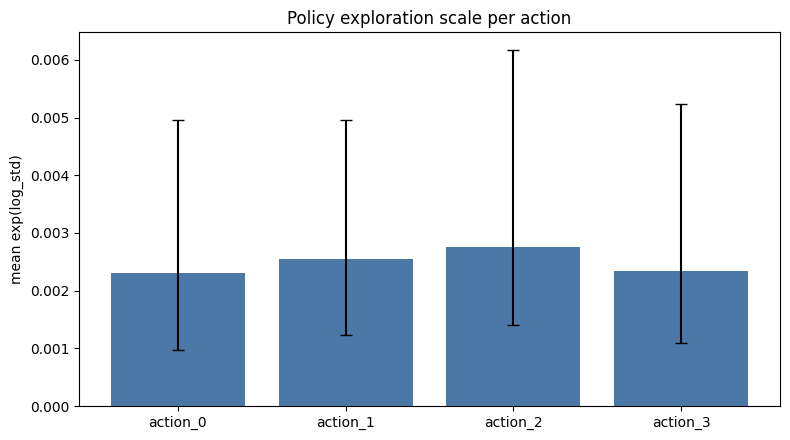

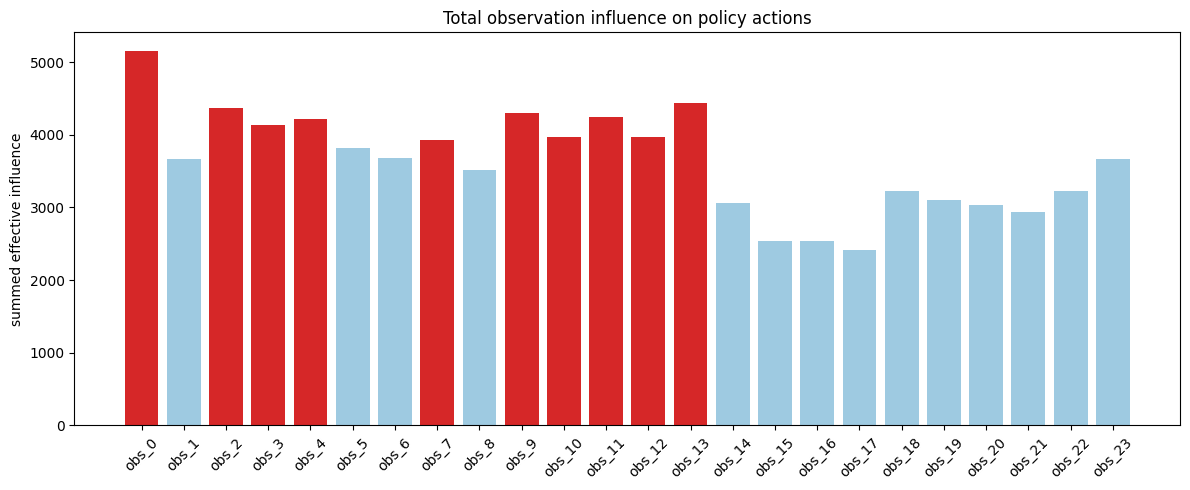

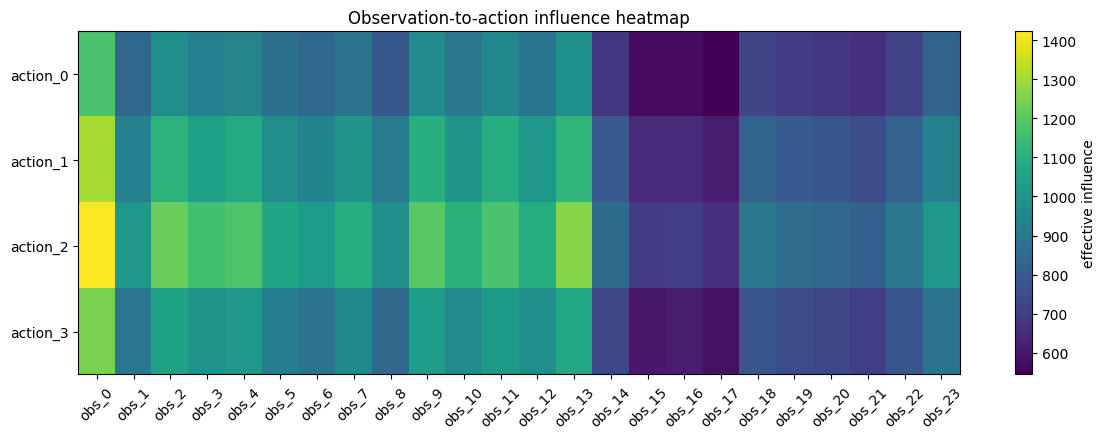

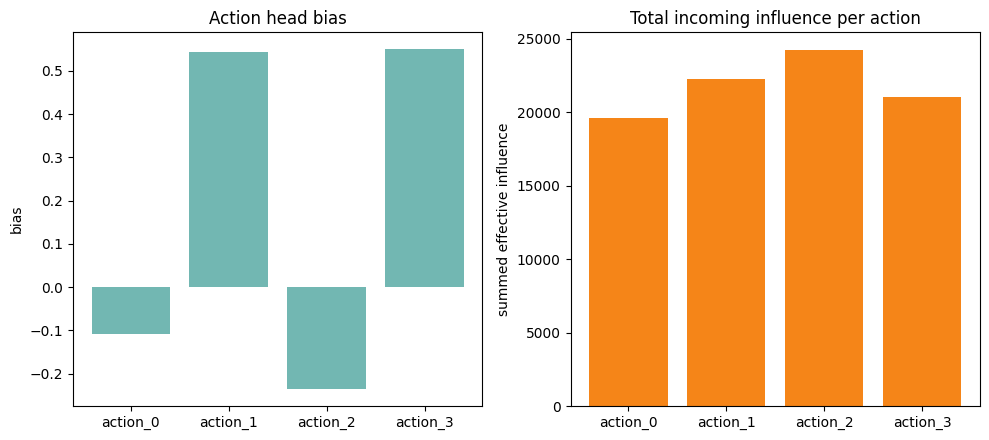


Interpretation:
- The first chart shows aggregated exploration scale per action.
- Red bars in the observation chart mark the most dominant inputs.
- The heatmap is a static weight-based heuristic, not a causal explanation.

Saved plots to: C:\Users\aleks\Desktop\Aleksie kerefeke\Python_Exercise\bipedal-walker-v3\policy_diagnostics


In [4]:
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from stable_baselines3.common.save_util import load_from_zip_file


OUT_DIR = Path("policy_diagnostics")
OUT_DIR.mkdir(exist_ok=True)

DEFAULT_CANDIDATES = [
    Path("policy.pth"),
    Path("artifacts/runs/standard/ppo_bipedalwalker_seed42/policy.zip"),
    Path("artifacts/archive/reports/runs/01_sb3_ppo_hardcore_baseline/policy/ppo_bipedalwalker_seed42.zip"),
]


def discover_policy_path() -> Path:
    for candidate in DEFAULT_CANDIDATES:
        if candidate.exists():
            return candidate

    recursive_candidates = sorted(Path("artifacts").rglob("*ppo*.zip")) + sorted(Path(".").rglob("policy.pth"))
    recursive_candidates = [path for path in recursive_candidates if ".venv" not in path.parts]
    if recursive_candidates:
        return recursive_candidates[0]

    searched = [str(path) for path in DEFAULT_CANDIDATES]
    raise FileNotFoundError("No PPO policy checkpoint found. Looked at: " + ", ".join(searched))


def load_policy_state_dict(policy_path: Path) -> dict[str, torch.Tensor]:
    if policy_path.suffix.lower() == ".zip":
        _, params, _ = load_from_zip_file(policy_path, device="cpu")
        if "policy" not in params:
            raise KeyError(f"SB3 archive does not contain 'policy' params: {policy_path}")
        return params["policy"]

    loaded = torch.load(policy_path, map_location="cpu")
    if isinstance(loaded, dict) and "state_dict" in loaded and isinstance(loaded["state_dict"], dict):
        return loaded["state_dict"]
    if isinstance(loaded, dict):
        return loaded

    raise TypeError(f"Unsupported checkpoint format: {type(loaded)}")


POLICY_PATH = discover_policy_path()
state_dict = load_policy_state_dict(POLICY_PATH)

required_keys = [
    "mlp_extractor.policy_net.0.weight",
    "mlp_extractor.policy_net.2.weight",
    "action_net.weight",
    "action_net.bias",
    "log_std",
]
missing = [key for key in required_keys if key not in state_dict]
if missing:
    raise KeyError(f"Checkpoint does not look like SB3 PPO MlpPolicy. Missing keys: {missing}")


W1 = state_dict["mlp_extractor.policy_net.0.weight"]
W2 = state_dict["mlp_extractor.policy_net.2.weight"]
Wa = state_dict["action_net.weight"]
ba = state_dict["action_net.bias"]
log_std = state_dict["log_std"]

obs_dim = int(W1.shape[1])
action_dim = int(Wa.shape[0])

log_std_np = log_std.detach().cpu().numpy()
action_std_matrix = np.exp(log_std_np).reshape(-1, action_dim)
action_std_mean = action_std_matrix.mean(axis=0)
action_std_min = action_std_matrix.min(axis=0)
action_std_max = action_std_matrix.max(axis=0)
action_bias = ba.detach().cpu().numpy().reshape(-1)
effective_influence = (torch.abs(Wa) @ torch.abs(W2) @ torch.abs(W1)).detach().cpu().numpy()
obs_total_influence = effective_influence.sum(axis=0)
action_total_influence = effective_influence.sum(axis=1)
top_obs_idx = np.argsort(-obs_total_influence)[: min(10, obs_dim)]

print(f"Loaded policy from: {POLICY_PATH}")
print(f"Observation dim: {obs_dim} | Action dim: {action_dim}")
print(f"log_std raw shape: {tuple(log_std.shape)}")

print("\n=== Top observation indices by influence ===")
for rank, idx in enumerate(top_obs_idx, start=1):
    print(f"{rank:>2}. obs_{idx:02d} -> influence={obs_total_influence[idx]:.4f}")

print("\n=== Action exploration scale summary ===")
for i in range(action_dim):
    print(
        f"action_{i}: mean_std={action_std_mean[i]:.4f} | "
        f"min_std={action_std_min[i]:.4f} | max_std={action_std_max[i]:.4f}"
    )

print("\n=== Action bias ===")
for i, bias in enumerate(action_bias):
    print(f"action_{i}: bias={bias:.4f}")


def save_show_close(fig: plt.Figure, filename: str) -> None:
    fig.tight_layout()
    fig.savefig(OUT_DIR / filename, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)


fig, ax = plt.subplots(figsize=(8, 4.5))
std_yerr = np.vstack([action_std_mean - action_std_min, action_std_max - action_std_mean])
ax.bar([f"action_{i}" for i in range(action_dim)], action_std_mean, yerr=std_yerr, color="#4c78a8", capsize=4)
ax.set_title("Policy exploration scale per action")
ax.set_ylabel("mean exp(log_std)")
save_show_close(fig, "01_action_std.png")

fig, ax = plt.subplots(figsize=(12, 5))
obs_colors = ["#d62728" if i in top_obs_idx else "#9ecae1" for i in range(obs_dim)]
ax.bar([f"obs_{i}" for i in range(obs_dim)], obs_total_influence, color=obs_colors)
ax.set_title("Total observation influence on policy actions")
ax.set_ylabel("summed effective influence")
ax.tick_params(axis="x", rotation=45)
save_show_close(fig, "02_obs_total_influence.png")

fig, ax = plt.subplots(figsize=(12, 4.5))
im = ax.imshow(effective_influence, aspect="auto", cmap="viridis")
fig.colorbar(im, ax=ax, label="effective influence")
ax.set_yticks(range(action_dim), [f"action_{i}" for i in range(action_dim)])
ax.set_xticks(range(obs_dim), [f"obs_{i}" for i in range(obs_dim)], rotation=45)
ax.set_title("Observation-to-action influence heatmap")
save_show_close(fig, "03_obs_action_heatmap.png")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].bar([f"action_{i}" for i in range(action_dim)], action_bias, color="#72b7b2")
axes[0].set_title("Action head bias")
axes[0].set_ylabel("bias")

axes[1].bar([f"action_{i}" for i in range(action_dim)], action_total_influence, color="#f58518")
axes[1].set_title("Total incoming influence per action")
axes[1].set_ylabel("summed effective influence")
save_show_close(fig, "04_action_bias_and_influence.png")

print("\nInterpretation:")
print("- The first chart shows aggregated exploration scale per action.")
print("- Red bars in the observation chart mark the most dominant inputs.")
print("- The heatmap is a static weight-based heuristic, not a causal explanation.")
print(f"\nSaved plots to: {OUT_DIR.resolve()}")


## Hardcore vs public leaderboard reference

This cell reproduces the presentation-ready comparison from `hardcore_leaderboard_compare.py` directly inside the notebook and saves the chart to `artifacts/plots/hardcore_vs_leaderboard_reference.png`.


In [ ]:
from __future__ import annotations

import csv
import json
import re
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

try:
    from IPython import get_ipython
except ImportError:
    get_ipython = None

if get_ipython is None or get_ipython() is None:
    matplotlib.use("Agg")

ROOT = Path(".").resolve()
ARTIFACTS = ROOT / "artifacts"
PLOTS_DIR = ARTIFACTS / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = PLOTS_DIR / "hardcore_vs_leaderboard_reference.png"


def short_label(text: str, max_len: int = 42) -> str:
    return text if len(text) <= max_len else text[: max_len - 3] + "..."


def first_existing_path(candidates: list[Path], label: str) -> Path:
    for candidate in candidates:
        if candidate.exists():
            return candidate
    searched = ", ".join(str(path) for path in candidates)
    raise FileNotFoundError(f"Could not find {label}. Looked at: {searched}")


def load_leaderboard(path: Path) -> list[dict[str, object]]:
    with path.open(encoding="utf-8") as handle:
        reader = csv.DictReader(handle)
        rows = []
        for row in reader:
            rows.append(
                {
                    "ranking": int(row["Ranking"]),
                    "model": row["Model"].strip(),
                    "mean": float(row["Mean Reward"]),
                    "std": float(row["Std Reward"]),
                }
            )
    return rows


def load_custom_eval(path: Path) -> tuple[float, float]:
    data = json.loads(path.read_text(encoding="utf-8"))
    evaluation = data["evaluation"]
    return float(evaluation["mean_reward"]), float(evaluation["std_reward"])


def load_sb3_eval(path: Path) -> tuple[float, float]:
    data = json.loads(path.read_text(encoding="utf-8"))
    return float(data["eval_mean_reward"]), float(data["eval_std_reward"])


def load_best_periodic_eval(path: Path) -> tuple[float, int]:
    best_mean: float | None = None
    best_episode: int | None = None
    pattern = re.compile(r"Eval @ episode (\d+) \| raw_mean=([-0-9.]+)")

    for line in path.read_text(encoding="utf-8").splitlines():
        match = pattern.search(line)
        if not match:
            continue
        episode = int(match.group(1))
        mean = float(match.group(2))
        if best_mean is None or mean > best_mean:
            best_mean = mean
            best_episode = episode

    if best_mean is None or best_episode is None:
        raise ValueError(f"Could not parse periodic clean evals from {path}")

    return best_mean, best_episode


def approximate_rank(rows: list[dict[str, object]], mean: float) -> int:
    return 1 + sum(1 for row in rows if float(row["mean"]) > mean)


LEADERBOARD_PATH = first_existing_path(
    [
        ARTIFACTS / "bipedalwalker_leaderboard.csv",
        ROOT / "bipedalwalker_leaderboard.csv",
    ],
    "leaderboard CSV",
)

leaderboard_rows = load_leaderboard(LEADERBOARD_PATH)
top_n = 10
top_rows = sorted(leaderboard_rows, key=lambda row: int(row["ranking"]))[:top_n]

u8_peak_mean, u8_peak_episode = load_best_periodic_eval(
    ARTIFACTS / "runs" / "hardcore" / "res_train_a001_as" / "train.log"
)
u7_eval_mean, u7_eval_std = load_custom_eval(
    ARTIFACTS / "runs" / "hardcore" / "fix_eval_best_raw" / "test_summary.json"
)
u8_eval_mean, u8_eval_std = load_custom_eval(
    ARTIFACTS / "runs" / "hardcore" / "res_eval_best_raw" / "test_summary.json"
)
u5_eval_mean, u5_eval_std = load_custom_eval(
    ARTIFACTS / "runs" / "hardcore" / "legacy_sac_lstm_h12_s42" / "test_summary.json"
)
u3_eval_mean, u3_eval_std = load_sb3_eval(
    ARTIFACTS / "runs" / "standard" / "ppo_bipedalwalker_seed42" / "test_summary.json"
)
u4_eval_mean, u4_eval_std = load_sb3_eval(
    ARTIFACTS / "runs" / "standard" / "td3_bipedalwalker_seed42" / "test_summary.json"
)

my_results = [
    {
        "label": "SAC-LSTM + anti-stall (best episode)",
        "mean": u8_peak_mean,
        "std": 0.0,
        "kind": "Mine",
        "color": "#1b9e77",
    },
    {
        "label": "SAC-LSTM + anti-stall (overall)",
        "mean": u8_eval_mean,
        "std": u8_eval_std,
        "kind": "Mine",
        "color": "#2ca02c",
    },
    {
        "label": "SAC-LSTM + anti-stall (breakthrough)",
        "mean": u7_eval_mean,
        "std": u7_eval_std,
        "kind": "Mine",
        "color": "#ff7f0e",
    },
    {
        "label": "SAC-LSTM",
        "mean": u5_eval_mean,
        "std": u5_eval_std,
        "kind": "Mine",
        "color": "#9467bd",
    },
    {
        "label": "SB3 PPO",
        "mean": u3_eval_mean,
        "std": u3_eval_std,
        "kind": "Mine",
        "color": "#d62728",
    },
    {
        "label": "SB3 TD3",
        "mean": u4_eval_mean,
        "std": u4_eval_std,
        "kind": "Mine",
        "color": "#8c564b",
    },
]

for result in my_results:
    result["approx_rank"] = approximate_rank(leaderboard_rows, float(result["mean"]))
    result["plot_label"] = f"{result['label']} (~ #{result['approx_rank']})"

leaderboard_plot_rows = [
    {
        "plot_label": f"#{int(row['ranking'])} {short_label(str(row['model']))}",
        "mean": float(row["mean"]),
        "std": float(row["std"]),
        "kind": "Leaderboard",
        "color": "#d9d9d9",
    }
    for row in top_rows
]

combined_rows = leaderboard_plot_rows + my_results
combined_rows = sorted(combined_rows, key=lambda row: float(row["mean"]))
my_rows_sorted = sorted(my_results, key=lambda row: float(row["mean"]))

plt.style.use("seaborn-v0_8-whitegrid")
fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(15, 14),
    gridspec_kw={"height_ratios": [1.5, 1.0]},
)

ax1.barh(
    [row["plot_label"] for row in combined_rows],
    [float(row["mean"]) for row in combined_rows],
    xerr=[float(row["std"]) for row in combined_rows],
    color=[str(row["color"]) for row in combined_rows],
    alpha=0.95,
)
ax1.axvline(300, linestyle="--", linewidth=1.2, color="black")
ax1.axvline(0, linestyle=":", linewidth=1.0, color="#666666")
ax1.set_title("My Hardcore Results vs Public BipedalWalker Leaderboard", fontsize=16, weight="bold")
ax1.set_xlabel("Mean reward")
ax1.set_ylabel("")
ax1.tick_params(axis="y", labelsize=9)
ax1.legend(
    handles=[
        Patch(facecolor="#d9d9d9", label=f"Leaderboard top {top_n}"),
        Patch(facecolor="#1b9e77", label="My hardcore runs"),
        Line2D([0], [0], color="black", lw=1.2, label="Black whiskers = +/- 1 std"),
    ],
    loc="lower right",
)

ax2.barh(
    [str(row["label"]) for row in my_rows_sorted],
    [float(row["mean"]) for row in my_rows_sorted],
    xerr=[float(row["std"]) for row in my_rows_sorted],
    color=[str(row["color"]) for row in my_rows_sorted],
    alpha=0.95,
)
ax2.axvline(0, linestyle=":", linewidth=1.0, color="#666666")
ax2.set_title("Zoom: My Best Hardcore Results", fontsize=14, weight="bold")
ax2.set_xlabel("Mean reward")
ax2.set_ylabel("")

min_x = min(float(row["mean"]) - float(row["std"]) for row in my_rows_sorted) - 20
max_x = max(float(row["mean"]) + float(row["std"]) for row in my_rows_sorted) + 30
ax2.set_xlim(min_x, max_x)

for row in my_rows_sorted:
    mean = float(row["mean"])
    std = float(row["std"])
    x_pos = mean + std + 6 if mean >= 0 else mean - std - 6
    ax2.text(
        x_pos,
        str(row["label"]),
        f"{mean:.2f}",
        va="center",
        ha="left" if mean >= 0 else "right",
        fontsize=10,
        weight="bold",
    )

fig.text(
    0.01,
    0.01,
    (
        "Bars show mean reward. Black whiskers show +/- 1 standard deviation across evaluation episodes.\n"
        "Reference note: the public CSV used in result_analsys.ipynb is for BipedalWalker-v3, "
        "not a dedicated BipedalWalkerHardcore-v3 leaderboard. This chart is therefore a "
        "presentation-friendly external reference comparison, not a strict apples-to-apples ranking."
    ),
    ha="left",
    fontsize=10,
)

plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.savefig(OUTPUT_PATH, dpi=220, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Saved chart: {OUTPUT_PATH}")
print()
print("Approximate positions vs public BipedalWalker-v3 leaderboard by mean reward:")
for row in sorted(my_results, key=lambda item: float(item["mean"]), reverse=True):
    extra = f", source_episode={u8_peak_episode}" if row["label"] == "SAC-LSTM + anti-stall (best episode)" else ""
    print(
        f"- {row['label']}: mean={float(row['mean']):.2f}, "
        f"approx_rank={int(row['approx_rank'])}{extra}"
    )
